In [1]:
from plots import plot_policy_convergence, plot_final_policies, plot_final_policies_linear, plot_specific_state_policy, plot_specific_state_policy_linear
from plots import plot_policy, plot_transition_matrix
import pickle

In [2]:
from matplotlib import pyplot as plt
import numpy as np
import copy
from pathlib import Path

In [3]:
import os
os.getcwd()

'/Users/mathis/Documents/EPFL/Master_Thesis/CARMA-Congestion_Railway/0-Simulation'

In [4]:
path = "../results_1/"

with open(path + 'groups.pkl', 'rb') as f:
    groups = pickle.load(f)

with open(path + 'error_vec.pkl', 'rb') as f:
    error_vec = pickle.load(f)

with open(path + 'expected_value_vec.pkl', 'rb') as f:
    expected_value_vec = pickle.load(f)

with open(path + 'simulation_params.pkl', 'rb') as f:
    n_day, n_groups, K, n_travelers = pickle.load(f)

with open(path + 'system.pkl', 'rb') as f:
    system = pickle.load(f)

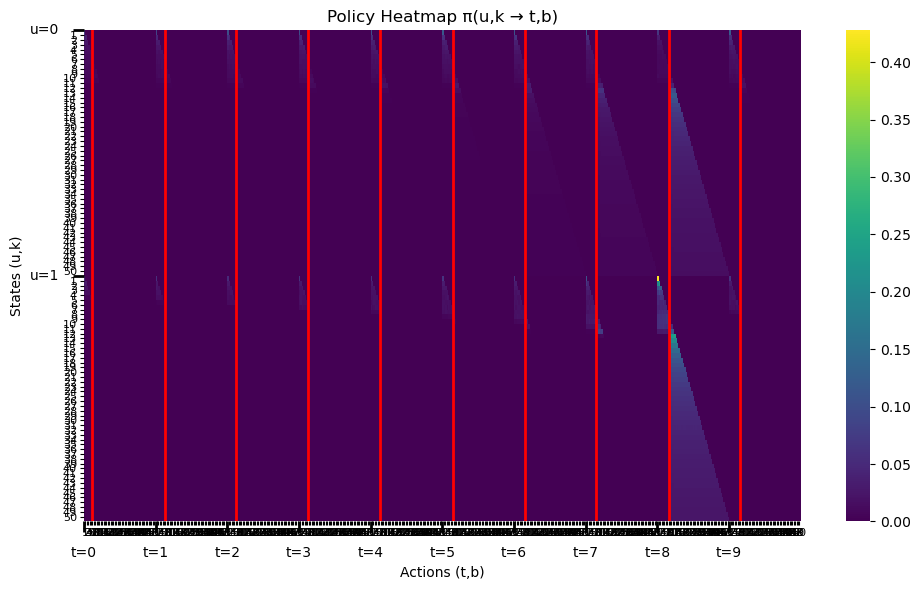

In [5]:
plot_policy(groups[0], b_star=system.b_star)

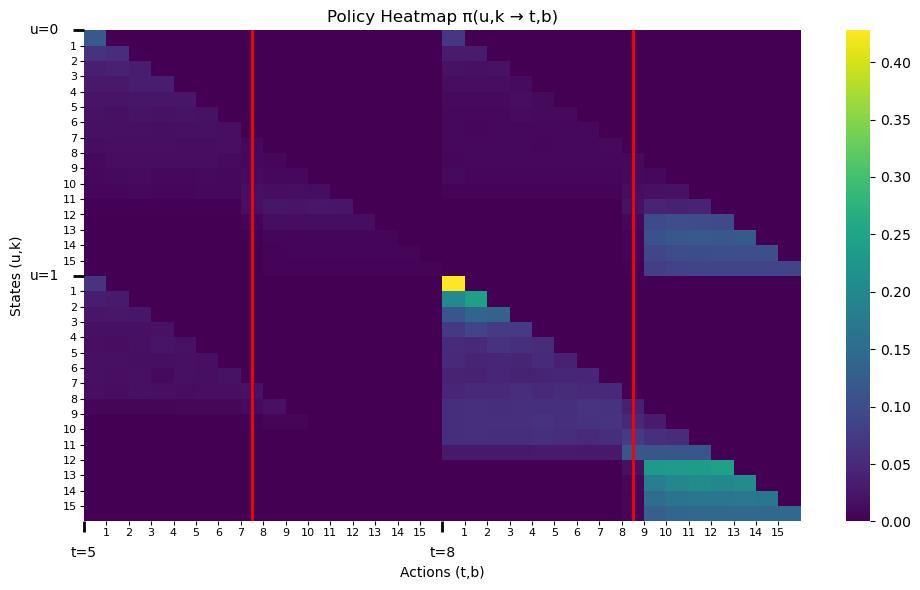

In [6]:
group = groups[0]

# plot_policy(group, b_star=system.b_star)  # full matrix
max_karma_level = 15 # for plotting
k_list = list(range(max_karma_level + 1))
b_list = k_list
plot_policy(group, u=[0,1], k=k_list, t=[5,8], b=b_list, b_star=system.b_star)


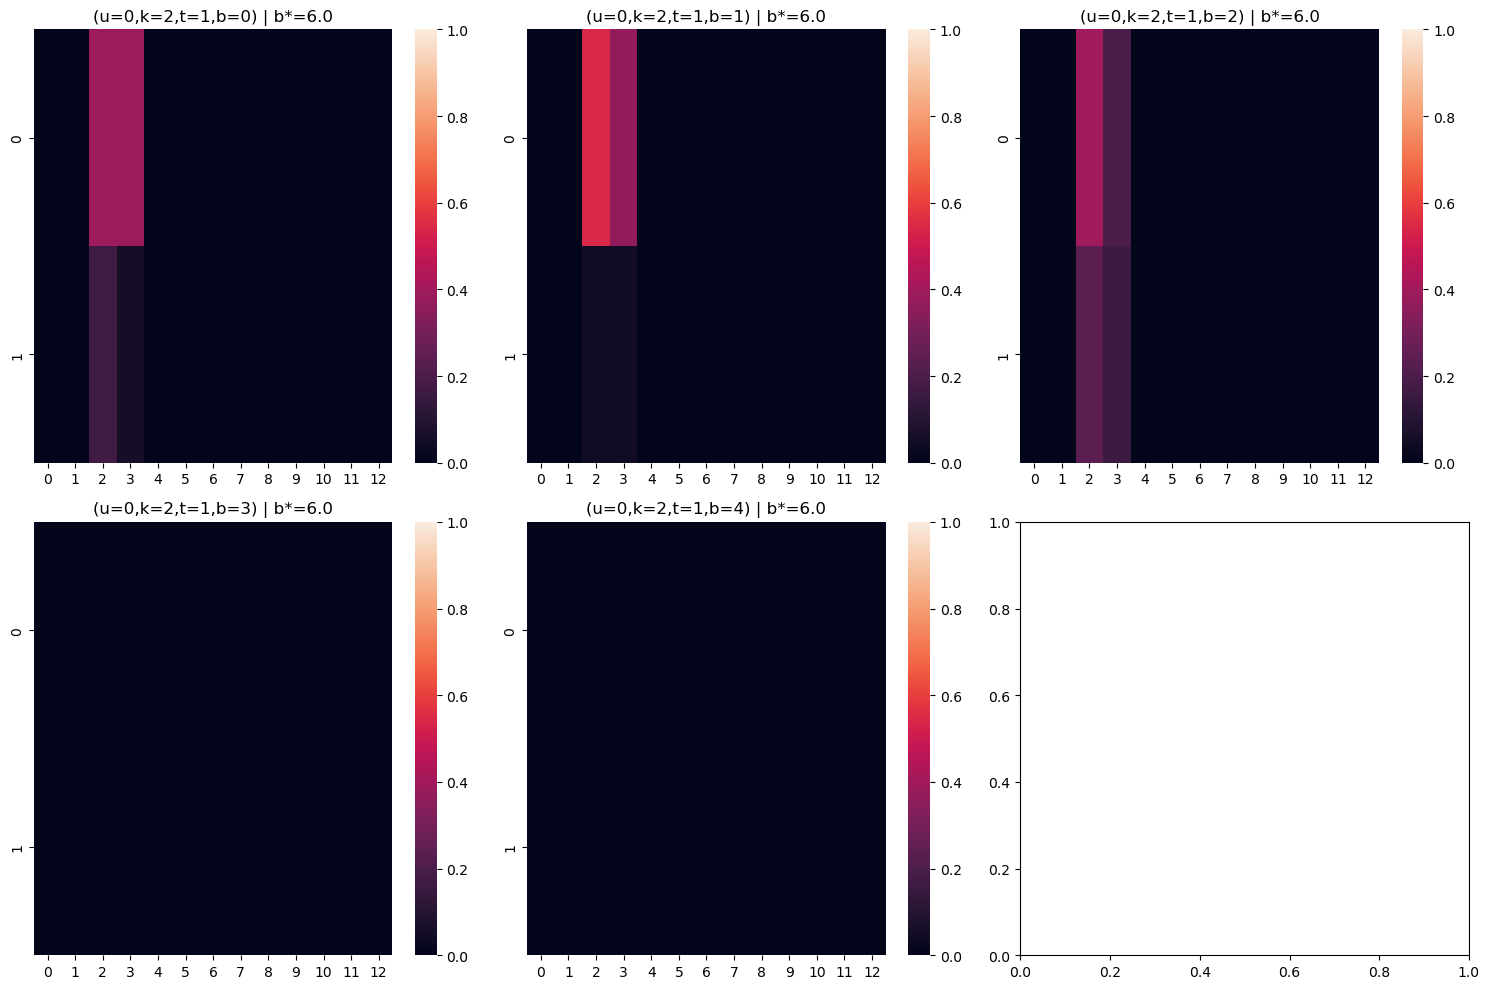

In [7]:
plot_transition_matrix(group, u=0, k=[2], t=1, b=[0,1,2,3,4], b_star=system.b_star, window_size=10)


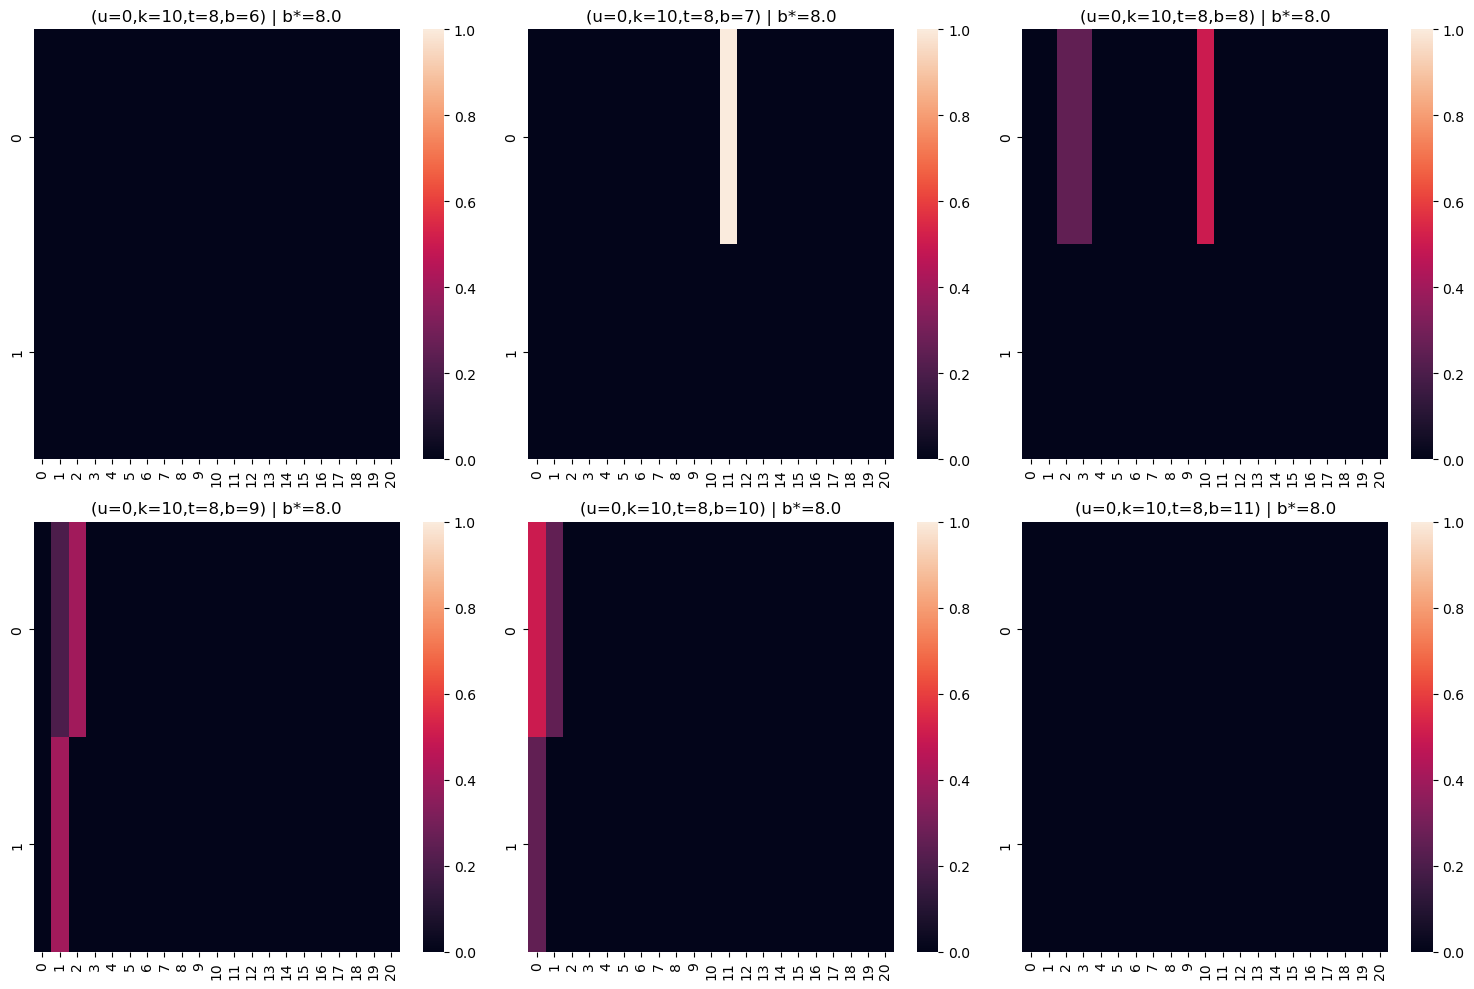

In [8]:
plot_transition_matrix(group, u=0, k=[10], t=8, b=[6,7,8,9,10,11], b_star=system.b_star, window_size=10)

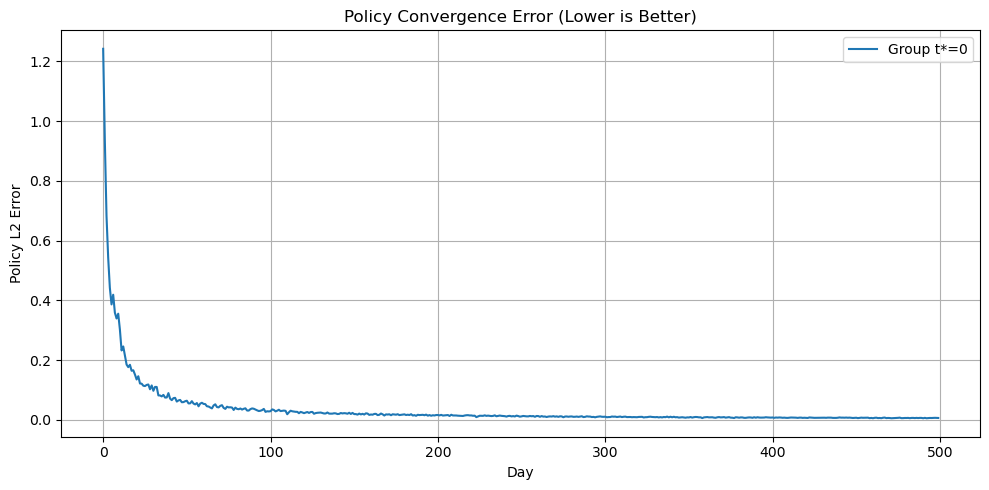

In [9]:
plot_policy_convergence(error_vec, n_day, n_groups)

In [10]:
print(error_vec[0])

[0.00641131]


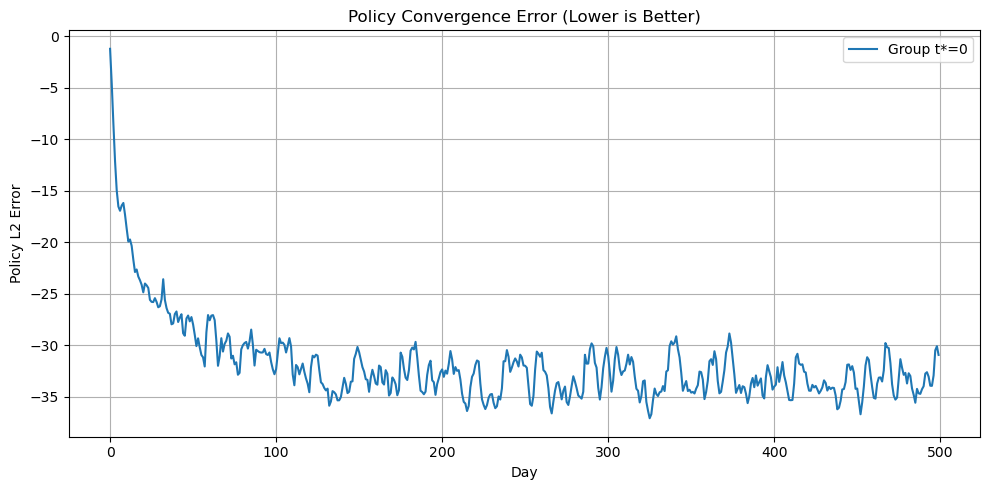

In [11]:
# for expected_value_vec
plot_policy_convergence(expected_value_vec, n_day, n_groups)

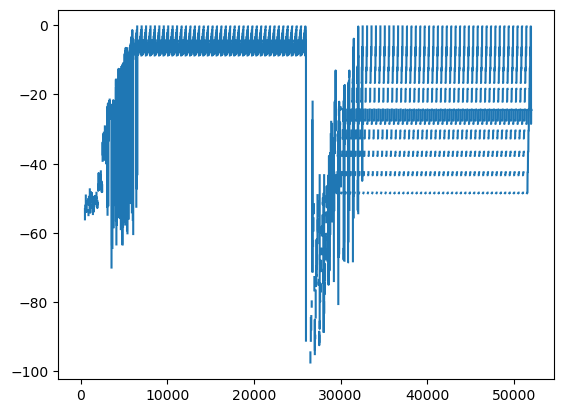

In [12]:
plt.plot(group.Q)

In [14]:
# here there is a mistake in the indexing of Q and pi


Q_reshaped = group.Q.reshape(group.pi.shape)

# state index
for u in range(group.U):
    for k in range(group.K + 1):
        state_index = u * (group.K + 1) + k
        # action_index
        for t in range(group.T):
            for b in range(group.K+1):
                action_index = t * (group.K + 1) + b

                # select a specific state and action to print
                if u == 0 and k ==1 and (b ==0 or b == 1):
                    print(f"State (u={u}, k={k}), Action (t={t}, b={b}): Q-value = {Q_reshaped[state_index, action_index]}, Policy action = {group.pi[state_index, action_index]}")

State (u=0, k=1), Action (t=0, b=0): Q-value = -53.10117643100083, Policy action = 0.03465531766414642
State (u=0, k=1), Action (t=0, b=1): Q-value = -56.05476302504416, Policy action = 0.03753285109996796
State (u=0, k=1), Action (t=1, b=0): Q-value = -53.65513812417232, Policy action = 0.04535317048430443
State (u=0, k=1), Action (t=1, b=1): Q-value = -52.10338548337729, Policy action = 0.04478752240538597
State (u=0, k=1), Action (t=2, b=0): Q-value = -49.185382359780434, Policy action = 0.06002208963036537
State (u=0, k=1), Action (t=2, b=1): Q-value = -53.69803854386086, Policy action = 0.04671904444694519
State (u=0, k=1), Action (t=3, b=0): Q-value = -53.89492290388067, Policy action = 0.05633506551384926
State (u=0, k=1), Action (t=3, b=1): Q-value = -53.432801299780834, Policy action = 0.04929015040397644
State (u=0, k=1), Action (t=4, b=0): Q-value = -51.68316132943231, Policy action = 0.06131104752421379
State (u=0, k=1), Action (t=4, b=1): Q-value = -53.40343155083293, Poli

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

n_iter = 10
u_values = [0, 1]
k = K
T = groups[0].T

fig, axes = plt.subplots(
    n_iter, 2,
    figsize=(9, 2.3 * n_iter),
    sharex=True, sharey=True
)

for it in range(n_iter):

    # ---- Store policy BEFORE update ----
    pi_before = {}
    for u in u_values:
        idx = u * (K + 1) + k
        pi_before[u] = groups[0].pi[idx].reshape(T, K+1).T

    # ---- One-day simulation ----
    travelers = groups[0].travelers

    # 1. Travelers act
    for tr in travelers:
        tr.store_start_state()
        tr.action()

    # 2. System queues
    system.simulate_class_attribution()

    # 3. Payment
    for tr in travelers:
        tr.paid_karma_bid()

    # 4. Redistribution
    system.karma_redistribution()

    # 5. Update urgency
    for tr in travelers:
        tr.update_urgency()

    # 6. Update each group (independent policies)
    for g in groups:
        g.update_group_attributes(system) 

        g.update_state_distribution()
        g.compute_expected_value_function()


    # ---- Plot ----
    for col, u in enumerate(u_values):
        ax = axes[it, col]

        im = ax.imshow(
            pi_before[u][:11],
            origin="lower",
            aspect="auto",
            vmin=0,
            vmax=0.1
        )

        if it == 0:
            ax.set_title(f"Urgency $u={u}$")

        if col == 0:
            ax.set_ylabel(f"Iter {it}\nBid $b$")

        if it == n_iter - 1:
            ax.set_xlabel("Departure time $t$")

# ---- Manual layout control ----
plt.subplots_adjust(
    left=0.08,
    right=0.88,
    top=0.92,
    bottom=0.08,
    hspace=0.35,
    wspace=0.15
)

# ---- Dedicated colorbar axis ----
cax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im, cax=cax)
cbar.set_label("Policy probability")

plt.show()
